In [ ]:
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("../../data_processed/SG_nona.csv", parse_dates=["date"])

df

,date,new_confirmed,new_deceased,new_tested,cumulative_confirmed,cumulative_deceased,new_persons_vaccinated,cumulative_persons_vaccinated,new_persons_fully_vaccinated,cumulative_persons_fully_vaccinated,...,search_trends_wheeze,search_trends_xeroderma,search_trends_xerostomia,search_trends_yawn,average_temperature_celsius,minimum_temperature_celsius,maximum_temperature_celsius,rainfall_mm,dew_point,relative_humidity
0,2020-01-01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.30,4.45,0.46,0.25,27.816667,25.400000,31.444444,0.406400,23.622222,78.160465
1,2020-01-02,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.31,4.33,0.44,0.19,27.483333,25.116667,30.522222,1.213556,24.072222,81.775103
2,2020-01-03,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.28,4.40,0.40,0.21,27.627778,25.266667,31.172222,0.793750,24.255556,82.004853
3,2020-01-04,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.29,4.78,0.42,0.21,27.200000,24.700000,30.883333,1.682750,23.800000,81.865993
4,2020-01-05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.28,4.44,0.41,0.24,27.744444,24.811111,31.872222,0.431800,23.477778,77.721261
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
986,2022-09-13,2426.0,2.0,24000.0,1867168.0,1604.0,60.0,5024384.0,195.0,5004693.0,...,0.39,4.03,0.41,0.22,26.888889,24.544444,30.833333,6.508750,23.700000,82.993906
987,2022-09-14,2426.0,2.0,24000.0,1867168.0,1604.0,60.0,5024384.0,195.0,5004693.0,...,0.39,4.03,0.41,0.22,26.888889,24.544444,30.833333,6.508750,23.700000,82.993906
988,2022-09-15,2426.0,2.0,24000.0,1867168.0,1604.0,60.0,5024384.0,195.0,5004693.0,...,0.39,4.03,0.41,0.22,26.888889,24.544444,30.833333,6.508750,23.700000,82.993906
989,2022-09-16,2426.0,2.0,24000.0,1867168.0,1604.0,60.0,5024384.0,195.0,5004693.0,...,0.39,4.03,0.41,0.22,26.888889,24.544444,30.833333,6.508750,23.700000,82.993906


# Testing Time Series Analysis

In [3]:
import pmdarima as pm
from prophet import Prophet

/home/karol/Pulpit/MIMUW/Data_analysis_and_visualization/venv/lib64/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [4]:
sel_y_col: str = "search_trends_shyness"

In [5]:
df_to_forecast = df[["date", sel_y_col]].rename(columns={"date": "ds", sel_y_col: "y"})

df_to_forecast.head(3)

,ds,y
0,2020-01-01,0.64
1,2020-01-02,0.72
2,2020-01-03,0.68


In [6]:
m = Prophet()

m.fit(df_to_forecast)

df_times_predicted = m.make_future_dataframe(periods=365)

forecast = m.predict(df_times_predicted)

forecast

12:44:03 - cmdstanpy - INFO - Chain [1] start processing
12:44:03 - cmdstanpy - INFO - Chain [1] done processing


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2020-01-01,0.624923,0.545850,0.690123,0.624923,0.624923,-0.007992,-0.007992,-0.007992,0.008160,0.008160,0.008160,-0.016152,-0.016152,-0.016152,0.0,0.0,0.0,0.616931
1,2020-01-02,0.625346,0.544455,0.692134,0.625346,0.625346,-0.004653,-0.004653,-0.004653,0.003417,0.003417,0.003417,-0.008069,-0.008069,-0.008069,0.0,0.0,0.0,0.620693
2,2020-01-03,0.625769,0.546487,0.688440,0.625769,0.625769,-0.012266,-0.012266,-0.012266,-0.012091,-0.012091,-0.012091,-0.000174,-0.000174,-0.000174,0.0,0.0,0.0,0.613503
3,2020-01-04,0.626192,0.560704,0.709226,0.626192,0.626192,0.010239,0.010239,0.010239,0.002832,0.002832,0.002832,0.007407,0.007407,0.007407,0.0,0.0,0.0,0.636431
4,2020-01-05,0.626615,0.557633,0.696873,0.626615,0.626615,0.001570,0.001570,0.001570,-0.012987,-0.012987,-0.012987,0.014557,0.014557,0.014557,0.0,0.0,0.0,0.628186
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1351,2023-09-13,0.537068,0.477779,0.660677,0.490757,0.588633,0.032882,0.032882,0.032882,0.008160,0.008160,0.008160,0.024721,0.024721,0.024721,0.0,0.0,0.0,0.569949
1352,2023-09-14,0.536948,0.483157,0.659460,0.490456,0.588787,0.028581,0.028581,0.028581,0.003417,0.003417,0.003417,0.025164,0.025164,0.025164,0.0,0.0,0.0,0.565529
1353,2023-09-15,0.536828,0.462109,0.638610,0.490154,0.588853,0.013472,0.013472,0.013472,-0.012091,-0.012091,-0.012091,0.025563,0.025563,0.025563,0.0,0.0,0.0,0.550300
1354,2023-09-16,0.536708,0.482052,0.659141,0.489853,0.588918,0.028697,0.028697,0.028697,0.002832,0.002832,0.002832,0.025864,0.025864,0.025864,0.0,0.0,0.0,0.565405


In [9]:
model = pm.auto_arima(df_to_forecast["y"], seasonal=True)

In [11]:
ARIMA_forecast = model.predict(365)

# Plotting

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.axes import Axes

In [ ]:
def plot_scatter_on_ax(ax: Axes, df: pd.DataFrame, date_col: str = "ds", var_col: str = "yhat") -> None:
    ax.scatter(df[date_col], df[var_col], label = var_col, s = 1, marker = ".")

def configure_axis(ax: Axes, df_before: pd.DataFrame) -> None:
    ax.axhline(0, color = "black", ls = "-", lw = 0.5)
    ax.axvline(df_before.date[0], color = "black", ls = "-", lw = 0.5)

    ax.axvline(df_before.iloc[-1]["date"], ls = "--", color = f"C{1}", lw = 1, label = "Prediction Starting")


    ax.tick_params(axis='x', labelrotation=-45, labelsize = 7)
    ax.tick_params(axis='y', labelrotation=-45, labelsize = 7)

    ax.legend()
    ax.grid(True)

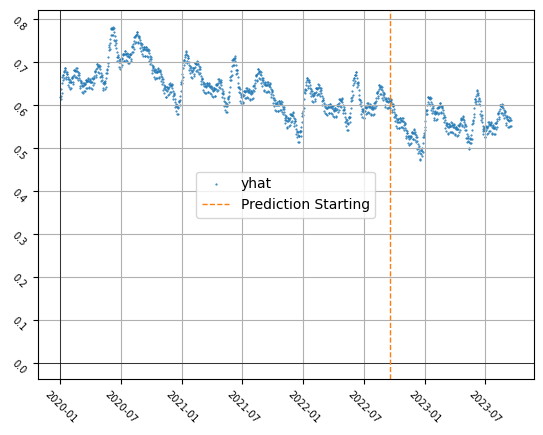

In [ ]:
fig, ax = plt.subplots()

axs = [ax]



for ax in axs:
    plot_scatter_on_ax(ax, forecast)

for ax in axs:
    configure_axis(ax=ax, df_before=df)

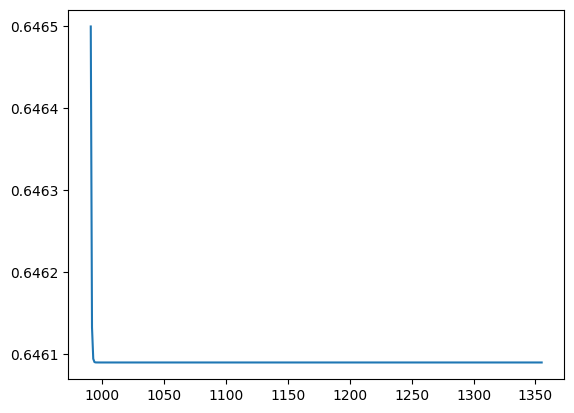